/tmp/ipykernel_2428/3435557051.py:52: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)
/opt/hostedtoolcache/Python/3.12.13/x64/lib/python3.12/site-packages/alphalens/utils.py:308: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = prices.pct_change(period)
/opt/hostedtoolcache/Python/3.12.13/x64/lib/python3.12/site-packages/alphalens/utils.py:308: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_m

Dropped 0.5% entries from factor data: 0.5% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 100.0%, not exceeded: OK!
Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,
1,-0.010206,-0.000023,-0.000373,0.000426,15583,20.855751
2,-0.002111,-0.000018,-0.000156,0.000156,14575,19.506678
3,-0.001228,-0.000011,-0.000101,0.000106,14515,19.426377
4,-0.000714,-0.000007,-0.000063,0.000071,14575,19.506678
5,-0.000532,0.000000,-0.000028,0.000044,15470,20.704516


Returns Analysis


,1D,5D,10D
Ann. alpha,0.201,0.190,0.182
beta,-0.113,-0.109,-0.086
Mean Period Wise Return Top Quantile (bps),6.849,6.146,6.240
Mean Period Wise Return Bottom Quantile (bps),-8.427,-6.711,-6.775
Mean Period Wise Spread (bps),15.276,12.787,12.973


<Figure size 640x480 with 0 Axes>

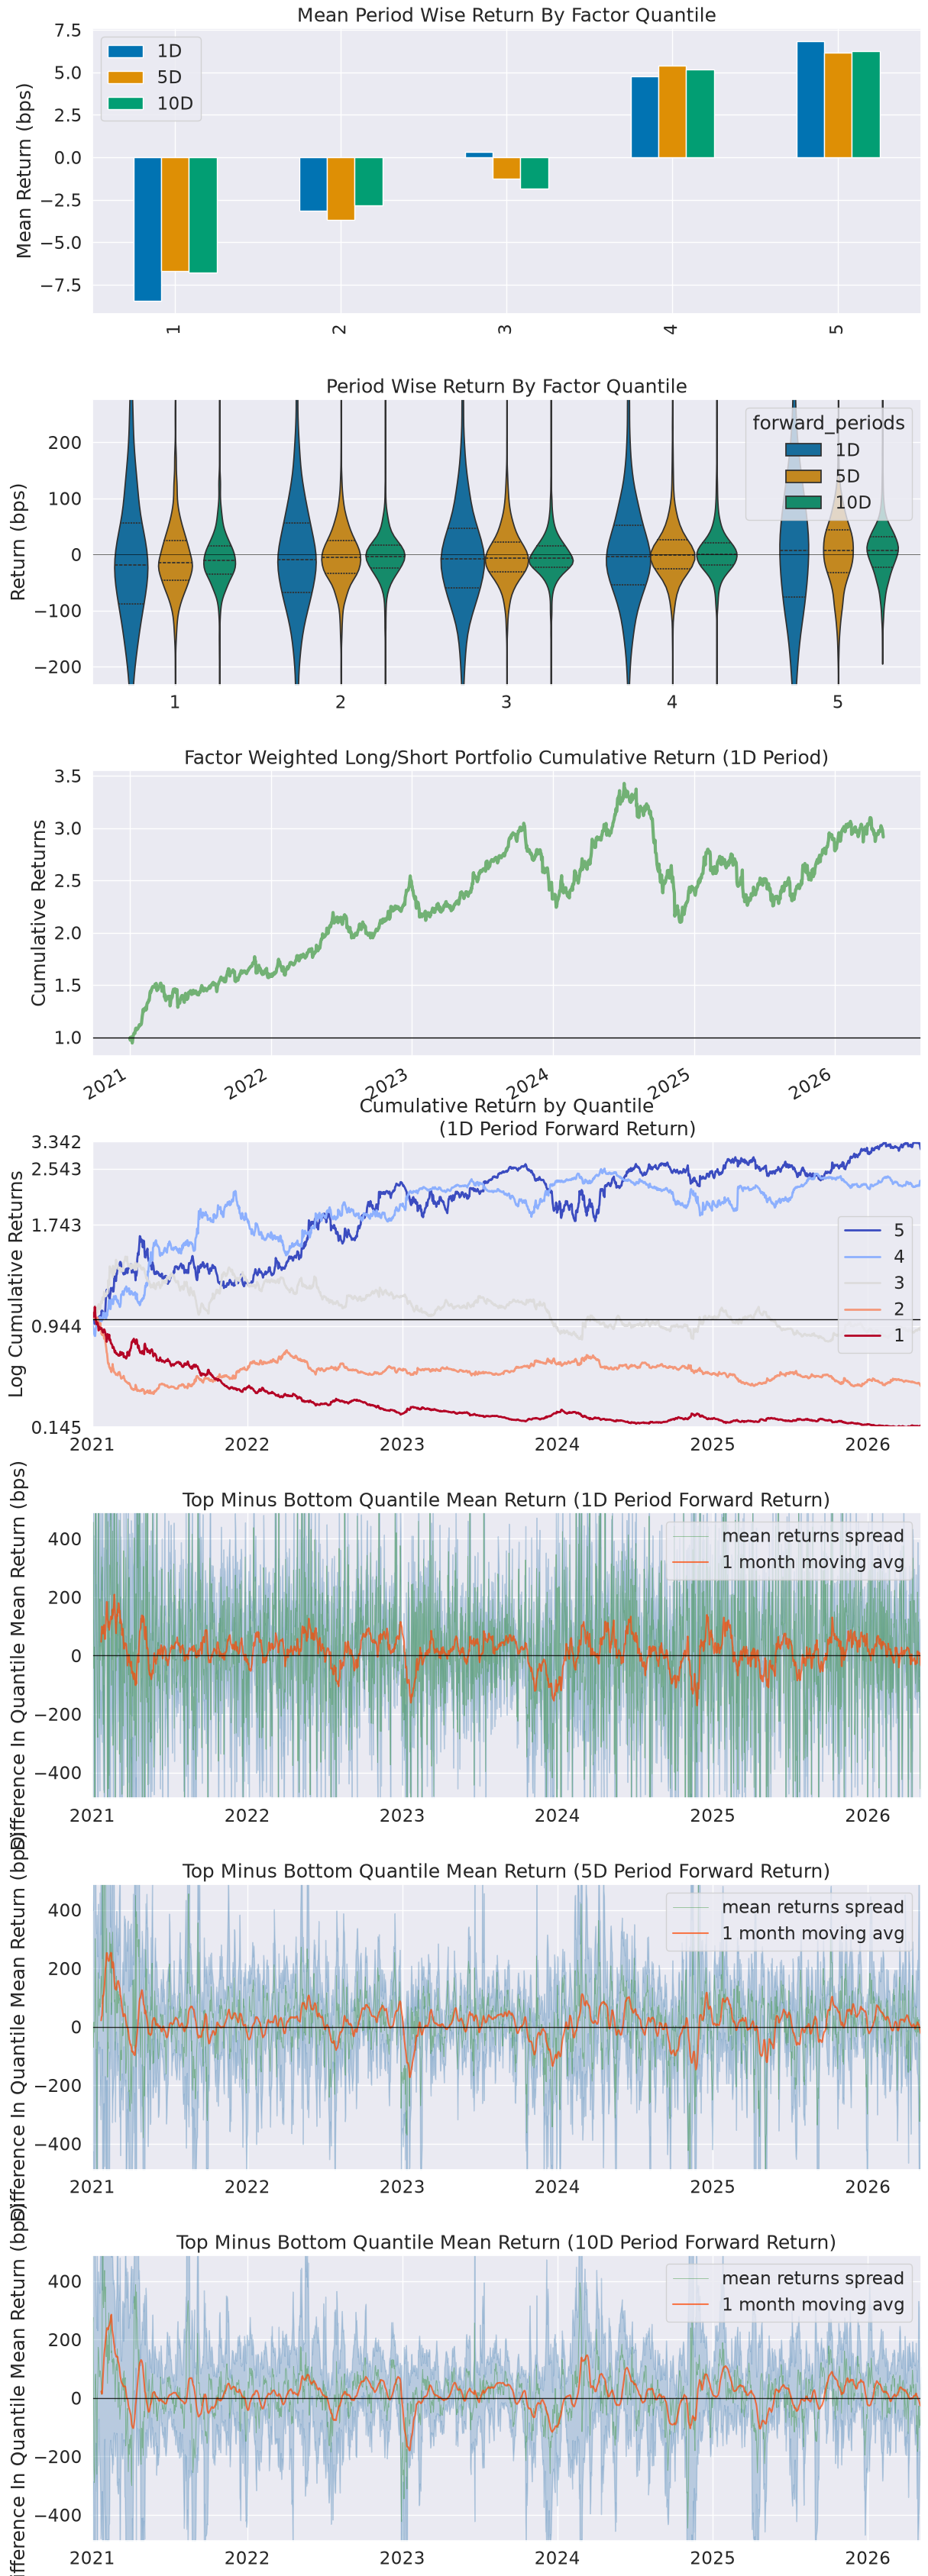

Information Analysis


,1D,5D,10D
IC Mean,0.047,0.069,0.084
IC Std.,0.267,0.264,0.258
Risk-Adjusted IC,0.177,0.261,0.327
t-stat(IC),7.823,11.517,14.438
p-value(IC),0.000,0.000,0.000
IC Skew,0.000,-0.043,-0.121
IC Kurtosis,-0.432,-0.554,-0.538


/opt/hostedtoolcache/Python/3.12.13/x64/lib/python3.12/site-packages/alphalens/performance.py:118: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  grouper.append(pd.Grouper(freq=by_time))


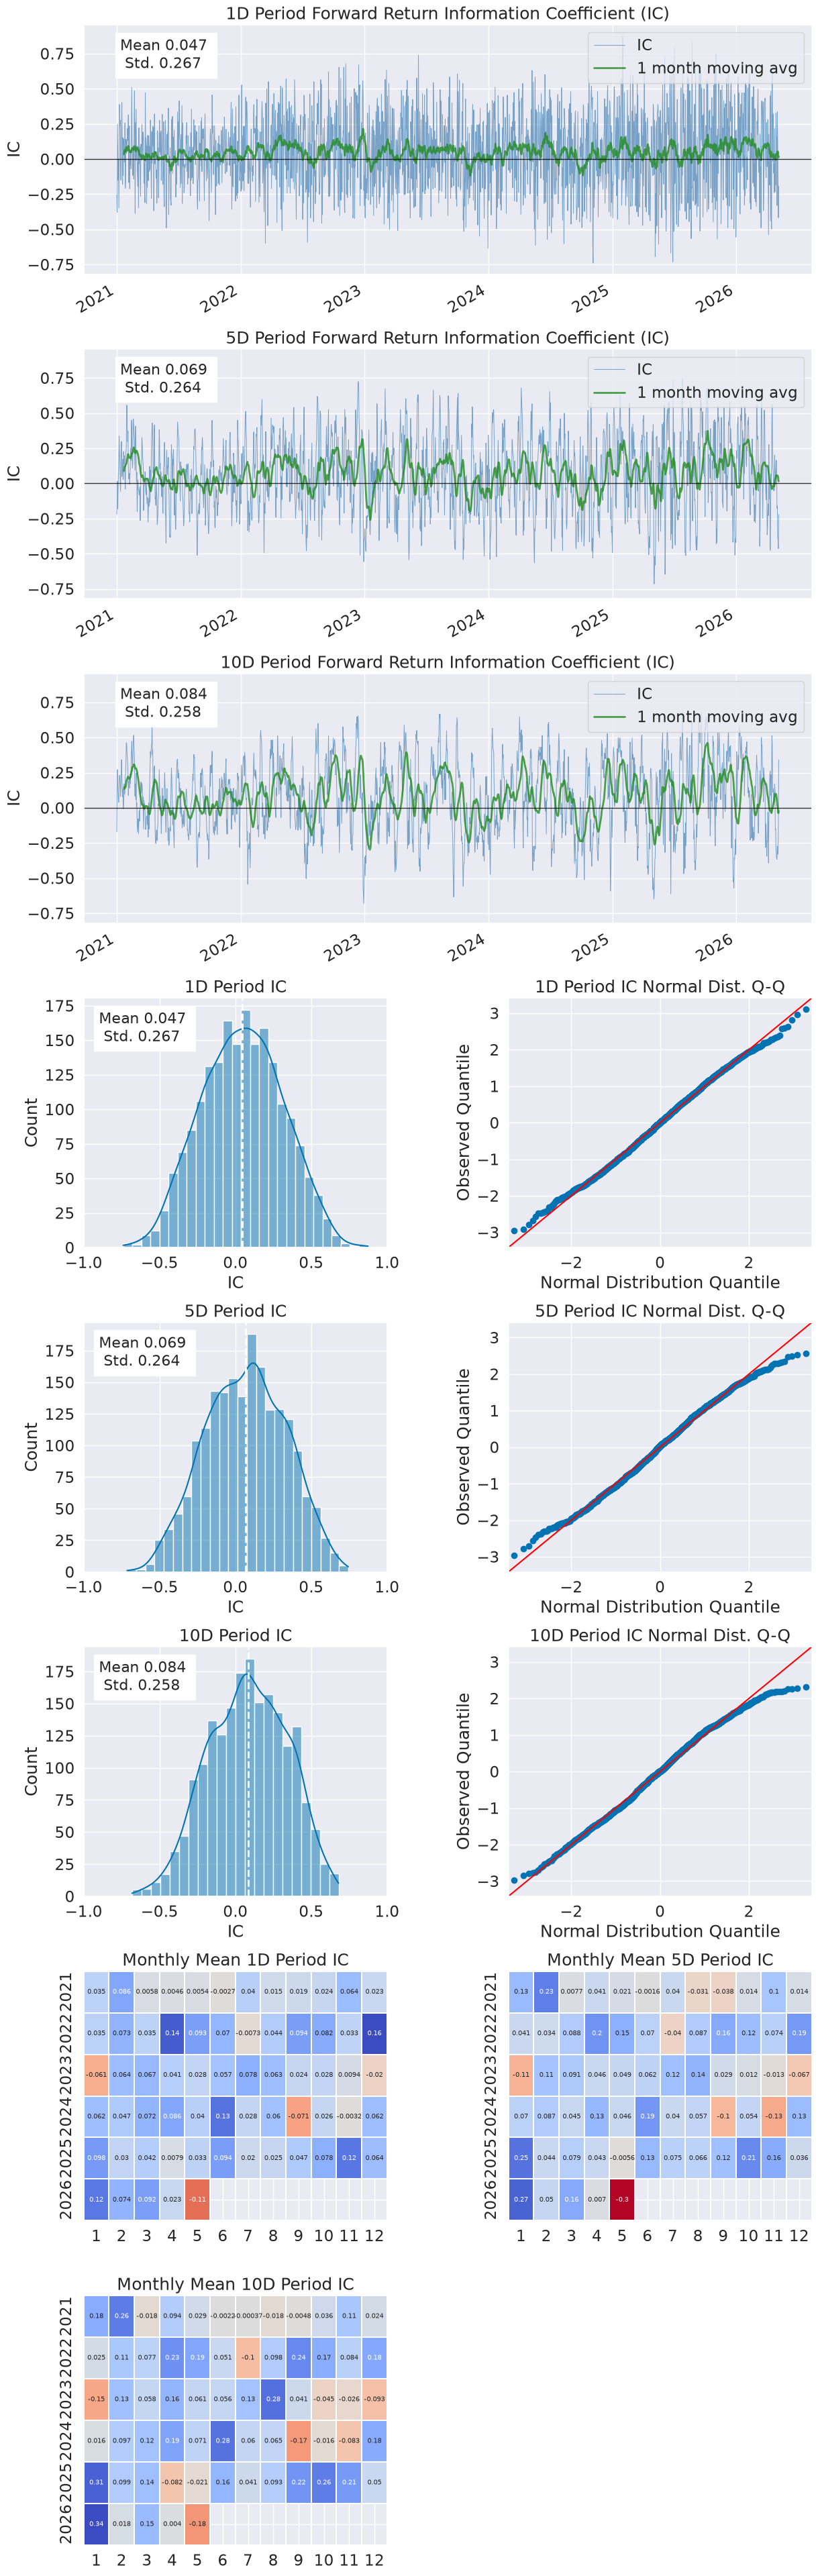

/opt/hostedtoolcache/Python/3.12.13/x64/lib/python3.12/site-packages/alphalens/utils.py:928: UserWarning: Skipping return periods that aren't exact multiples of days.
  warnings.warn(


Turnover Analysis


,1D,5D,10D
Quantile 1 Mean Turnover,0.098,0.251,0.352
Quantile 2 Mean Turnover,0.171,0.414,0.552
Quantile 3 Mean Turnover,0.188,0.440,0.582
Quantile 4 Mean Turnover,0.159,0.376,0.509
Quantile 5 Mean Turnover,0.070,0.179,0.258


,1D,5D,10D
Mean Factor Rank Autocorrelation,0.989,0.944,0.891


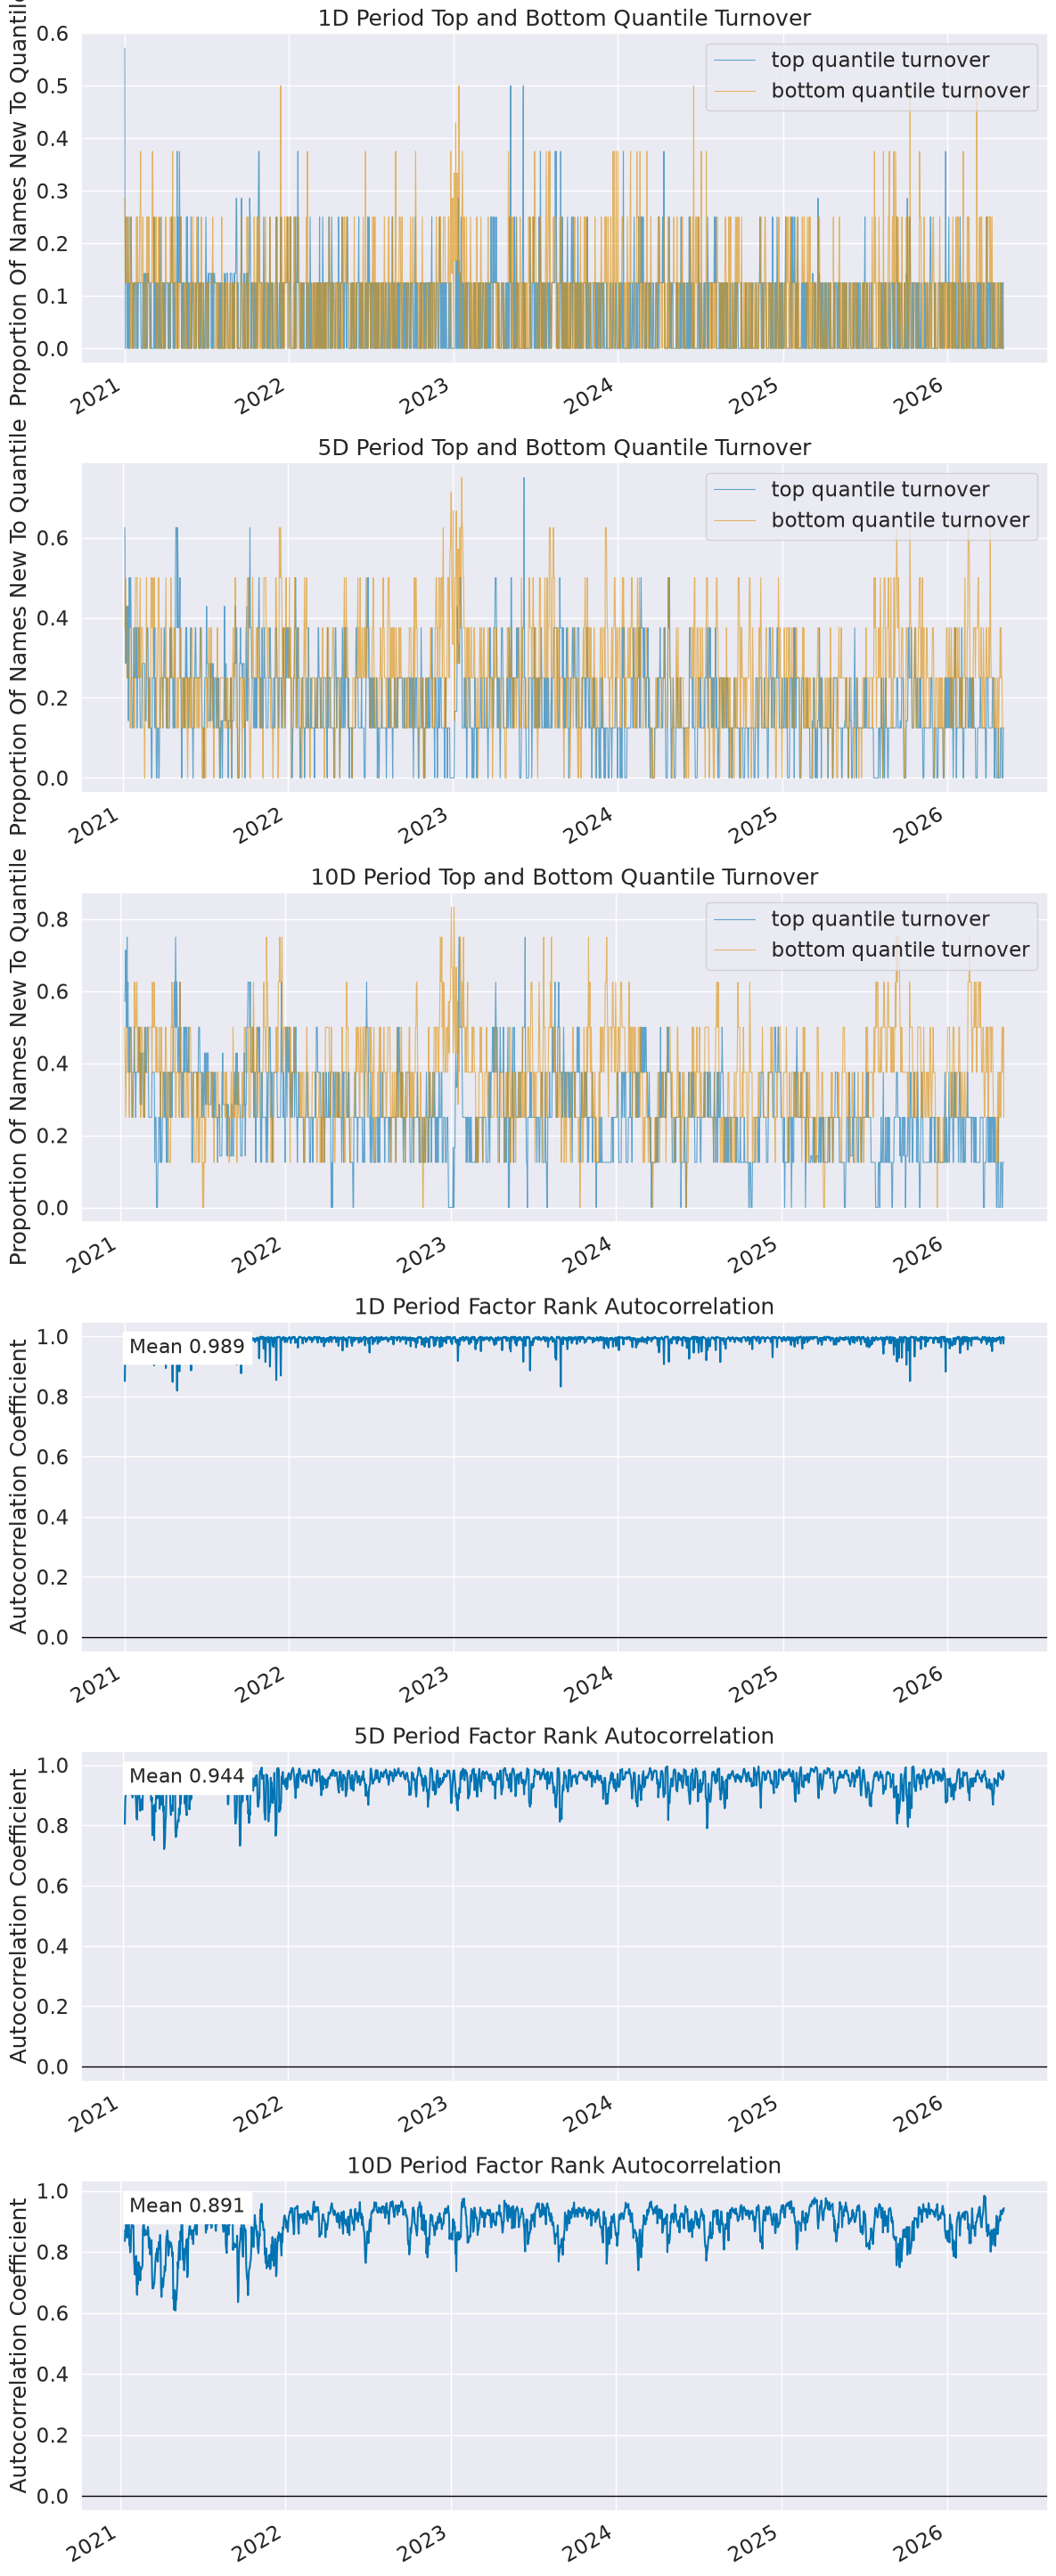

In [1]:
# AUTO-GENERATED from scripts/factors_catalog.py by
# scripts/generate_factor_notebooks.py -- do not edit by hand.
import sys
from pathlib import Path

_root = Path.cwd()
while not (_root / "notebooks" / "analysis").is_dir() and _root != _root.parent:
    _root = _root.parent
for _p in (_root, _root / "notebooks"):
    sys.path.insert(0, str(_p))

from aperiodic import (
    get_historical_universe,
    get_portfolio_factors_historical,
    get_prices,
    get_tickers,
)

from analysis.alphalens import factor_analysis
from analysis.utils import get_env

APERIODIC_API_KEY = get_env("APERIODIC_API_KEY")

# Margin Risk -- portfolio margin_risk.40
portfolio = "margin_risk"
universe_size = "40"

available_tickers = get_tickers(
    id=portfolio,
    api_key=APERIODIC_API_KEY,
    universe_size=universe_size,
    exchange=None,
)
historical_factors = get_portfolio_factors_historical(
    id=portfolio, tickers=available_tickers, api_key=APERIODIC_API_KEY
)
underlying = get_prices(tickers=available_tickers, api_key=APERIODIC_API_KEY)

# Mask the raw factor with the dynamic point-in-time universe (a boolean
# dates x tickers matrix) so AlphaLens scores only the universe we trade,
# not every ticker that was ever tradeable.
universe = get_historical_universe(
    size=universe_size,
    api_key=APERIODIC_API_KEY,
    start_date=str(historical_factors.index.min().date()),
    end_date=str(historical_factors.index.max().date()),
)
membership = (
    universe.reindex(index=historical_factors.index)
    .ffill()
    .reindex(columns=historical_factors.columns)
    .fillna(False)
    .astype(bool)
)
restricted_factors = historical_factors.where(membership)

columns_intersection = restricted_factors.columns.intersection(underlying.columns)
factor_analysis(restricted_factors[columns_intersection], underlying)